Lets do an Project on detectin the diabetics of a patient 

In [79]:
# Basic need for the operation 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as scp
import seaborn as sns

# Packages for Preprocessing of the Data 

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

# Structuring Preprocessing 

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline,make_pipeline

# ML Algo Packages

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

#Ensemble Methods 

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import ExtraTreesClassifier
import xgboost
import catboost
import lightgbm

# Evaluating Models

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Train Test Splitting

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [80]:
raw_data=pd.read_csv("diabetes_dataset.csv")


In [81]:
raw_data.head(10)

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,7.9,7.9,0,0,0,30.5,0.89,134,78,68,239,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,6.5,8.7,0,0,0,23.1,0.80,129,76,67,116,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,10.0,8.1,1,0,0,22.2,0.81,115,73,74,213,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,6.6,5.2,0,0,0,26.8,0.88,120,93,68,171,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,7.4,5.0,0,0,0,21.2,0.78,92,67,67,210,52,125,160,137,184,12.74,7.20,23.5,Type 2,1
5,46,Female,White,Highschool,Upper-Middle,Employed,Never,2,124,9.0,6.2,5.4,0,0,0,26.1,0.85,95,81,57,218,61,119,179,100,133,8.77,6.03,23.5,Pre-Diabetes,0
6,75,Female,White,Graduate,Upper-Middle,Retired,Never,0,53,9.2,7.8,8.0,0,1,0,25.1,0.88,129,77,81,238,46,161,155,101,100,10.14,5.24,36.1,Pre-Diabetes,0
7,62,Male,White,Postgraduate,Middle,Unemployed,Current,1,75,4.1,9.0,12.9,0,1,1,23.9,0.86,128,83,76,241,49,159,120,110,189,8.96,7.04,34.2,Type 2,1
8,42,Male,Black,Highschool,Lower-Middle,Employed,Current,1,114,6.7,8.5,8.5,0,0,1,24.7,0.84,103,71,72,187,33,132,98,116,172,5.70,6.90,26.7,Type 2,1
9,59,Female,White,Graduate,Middle,Employed,Current,3,86,8.2,5.3,7.4,0,0,0,26.7,0.81,124,81,70,188,52,103,104,76,109,4.49,4.99,30.0,No Diabetes,0


In [82]:
raw_data.isna().sum()

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


In [83]:
raw_data.dtypes

age                                     int64
gender                                 object
ethnicity                              object
education_level                        object
income_level                           object
employment_status                      object
smoking_status                         object
alcohol_consumption_per_week            int64
physical_activity_minutes_per_week      int64
diet_score                            float64
sleep_hours_per_day                   float64
screen_time_hours_per_day             float64
family_history_diabetes                 int64
hypertension_history                    int64
cardiovascular_history                  int64
bmi                                   float64
waist_to_hip_ratio                    float64
systolic_bp                             int64
diastolic_bp                            int64
heart_rate                              int64
cholesterol_total                       int64
hdl_cholesterol                   

In [84]:
raw_data["ID"]=range(1,len(raw_data)+1)

Checking for the Outliers 

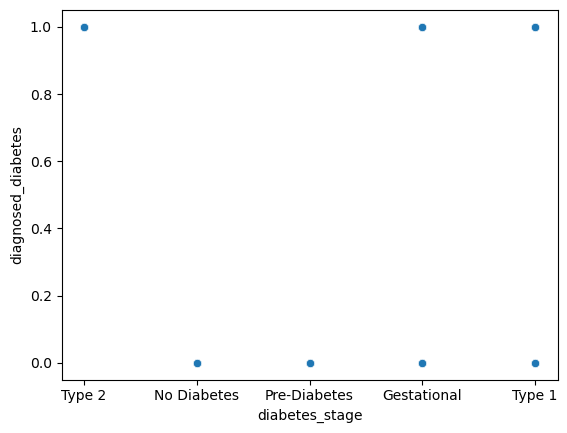

In [85]:
sns.scatterplot(x='diabetes_stage',y='diagnosed_diabetes',data=raw_data)
plt.show()

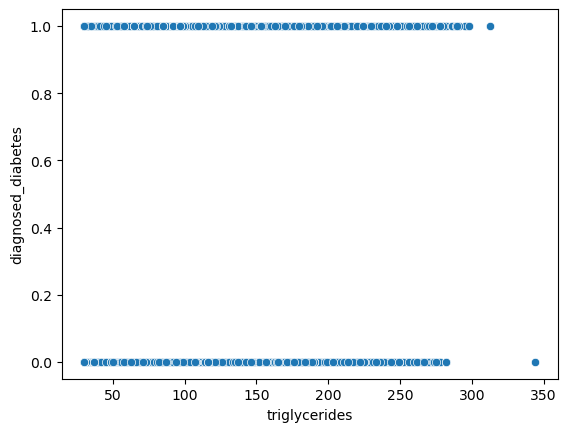

In [86]:
sns.scatterplot(x='triglycerides',y='diagnosed_diabetes',data=raw_data)
plt.show()

triglycerides=>300

In [87]:
trigly=raw_data[raw_data["triglycerides"]>300]

In [88]:
trigly

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes,ID
37055,65,Female,White,Graduate,Lower-Middle,Employed,Never,5,43,3.3,7.9,9.7,0,0,0,36.1,1.01,147,78,61,254,36,190,313,113,182,17.04,6.49,45.6,Type 2,1,37056
57427,29,Female,Black,Highschool,Upper-Middle,Employed,Current,3,373,5.0,6.6,9.8,0,0,0,39.0,0.95,129,60,54,229,42,159,344,108,174,16.99,6.47,25.4,Pre-Diabetes,0,57428


In [89]:
raw_data=raw_data[raw_data['ID']!=37056]
raw_data=raw_data[raw_data['ID']!=57428]

In [90]:
raw_data

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes,ID
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,7.9,7.9,0,0,0,30.5,0.89,134,78,68,239,41,160,145,136,236,6.36,8.18,29.6,Type 2,1,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,6.5,8.7,0,0,0,23.1,0.80,129,76,67,116,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0,2
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,10.0,8.1,1,0,0,22.2,0.81,115,73,74,213,66,99,36,118,195,5.07,7.51,44.7,Type 2,1,3
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,6.6,5.2,0,0,0,26.8,0.88,120,93,68,171,50,79,140,139,253,5.28,9.03,38.2,Type 2,1,4
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,7.4,5.0,0,0,0,21.2,0.78,92,67,67,210,52,125,160,137,184,12.74,7.20,23.5,Type 2,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46,Male,Other,Graduate,Upper-Middle,Unemployed,Former,1,136,8.3,6.4,4.5,0,0,0,29.8,0.93,126,74,63,227,45,150,116,113,109,14.58,5.55,26.0,Pre-Diabetes,0,99996
99996,41,Female,White,Graduate,Middle,Employed,Never,3,76,8.8,6.8,4.8,0,0,0,26.5,0.86,130,76,57,207,55,123,146,96,146,9.02,5.97,24.4,Pre-Diabetes,0,99997
99997,57,Female,Black,No formal,Upper-Middle,Employed,Former,4,121,9.9,5.0,6.1,0,0,1,25.6,0.83,107,87,69,189,50,111,184,93,132,2.57,5.21,27.6,No Diabetes,0,99998
99998,47,Female,Black,Highschool,Lower-Middle,Retired,Never,3,52,5.9,6.7,0.5,0,1,0,26.8,0.89,115,77,58,173,68,91,116,106,117,9.81,5.53,26.4,Pre-Diabetes,0,99999


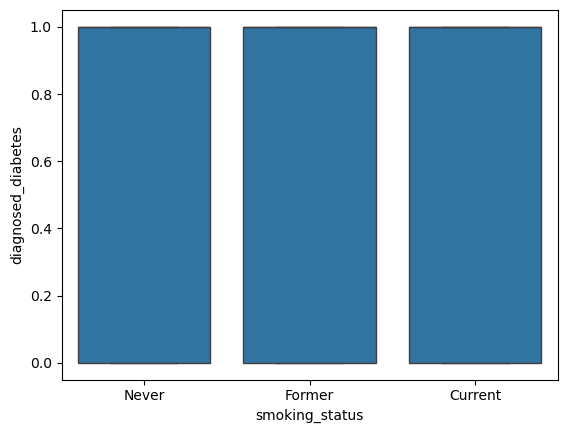

In [91]:
sns.boxplot(x='smoking_status',y='diagnosed_diabetes',data=raw_data)
plt.show()

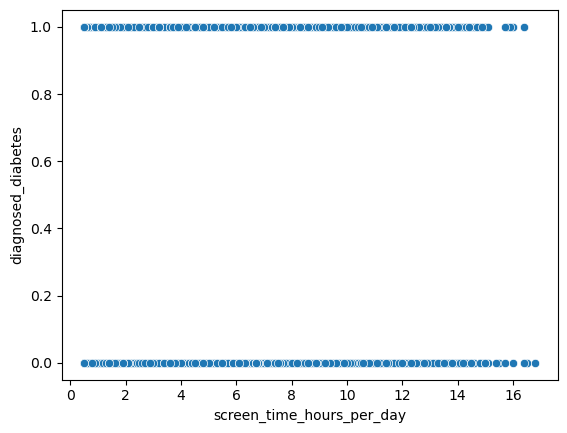

In [92]:
sns.scatterplot(x='screen_time_hours_per_day',y='diagnosed_diabetes',data=raw_data)
plt.show()

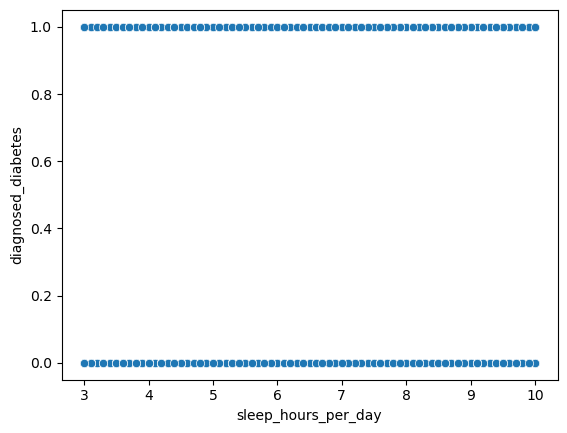

In [93]:


sns.scatterplot(x='sleep_hours_per_day',y='diagnosed_diabetes',data=raw_data)
plt.show()

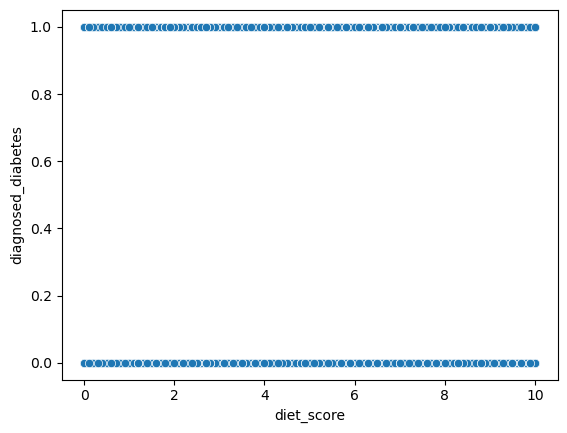

In [94]:


sns.scatterplot(x='diet_score',y='diagnosed_diabetes',data=raw_data)
plt.show()

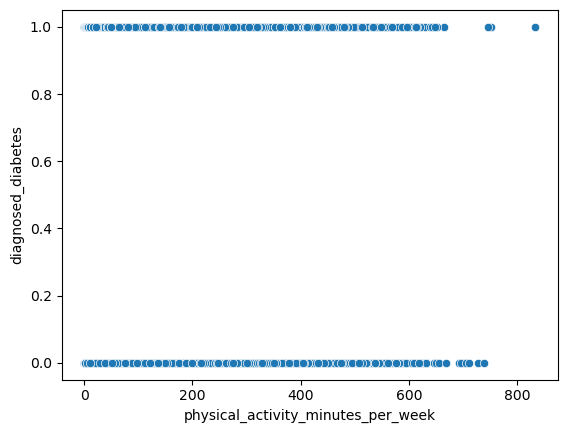

In [95]:

sns.scatterplot(x='physical_activity_minutes_per_week',y='diagnosed_diabetes',data=raw_data)
plt.show()

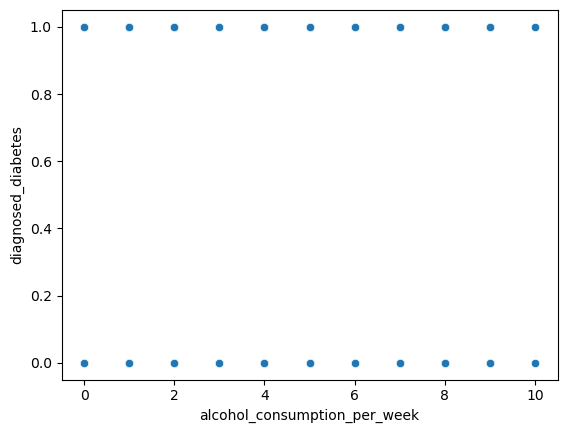

In [96]:
sns.scatterplot(x='alcohol_consumption_per_week',y='diagnosed_diabetes',data=raw_data)
plt.show()

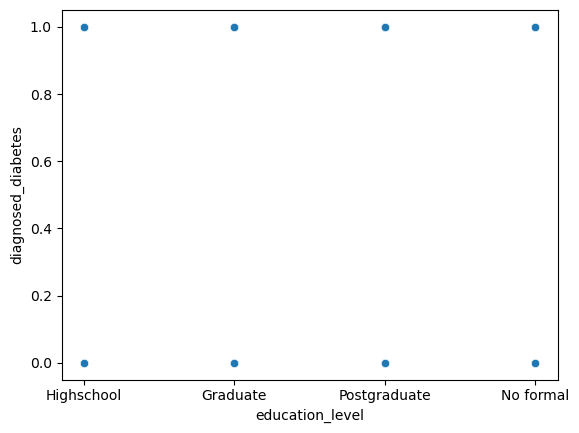

In [97]:
graph=plt.Figure(figsize=(4,6))
sns.scatterplot(x='education_level',y='diagnosed_diabetes',data=raw_data)
plt.show()

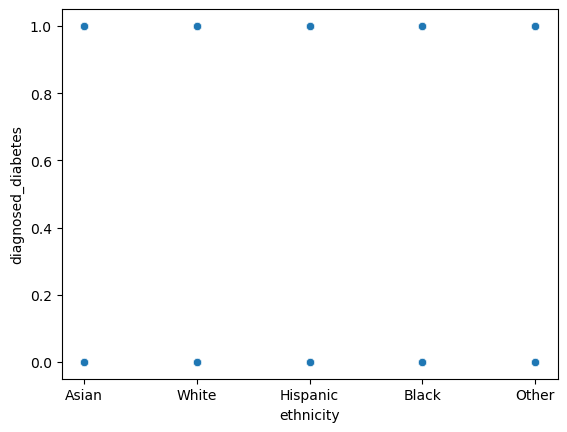

In [98]:
graph=plt.Figure(figsize=(4,6))
sns.scatterplot(x='ethnicity',y='diagnosed_diabetes',data=raw_data)
plt.show()

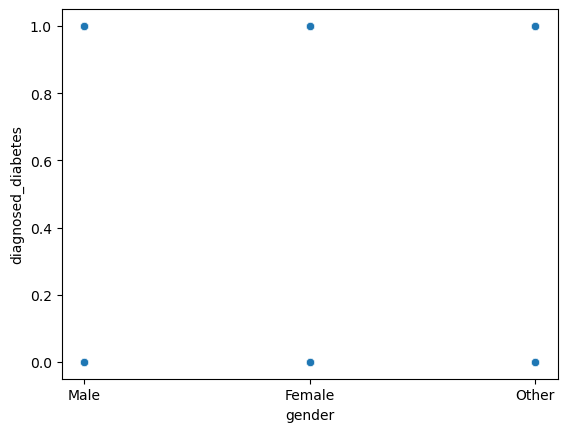

In [99]:
graph=plt.Figure(figsize=(4,6))
sns.scatterplot(x='gender',y='diagnosed_diabetes',data=raw_data)
plt.show()

Let Move to the Preprocssing of the data


In [100]:
raw_data.head(10)

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes,ID
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,7.9,7.9,0,0,0,30.5,0.89,134,78,68,239,41,160,145,136,236,6.36,8.18,29.6,Type 2,1,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,6.5,8.7,0,0,0,23.1,0.80,129,76,67,116,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0,2
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,10.0,8.1,1,0,0,22.2,0.81,115,73,74,213,66,99,36,118,195,5.07,7.51,44.7,Type 2,1,3
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,6.6,5.2,0,0,0,26.8,0.88,120,93,68,171,50,79,140,139,253,5.28,9.03,38.2,Type 2,1,4
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,7.4,5.0,0,0,0,21.2,0.78,92,67,67,210,52,125,160,137,184,12.74,7.20,23.5,Type 2,1,5
5,46,Female,White,Highschool,Upper-Middle,Employed,Never,2,124,9.0,6.2,5.4,0,0,0,26.1,0.85,95,81,57,218,61,119,179,100,133,8.77,6.03,23.5,Pre-Diabetes,0,6
6,75,Female,White,Graduate,Upper-Middle,Retired,Never,0,53,9.2,7.8,8.0,0,1,0,25.1,0.88,129,77,81,238,46,161,155,101,100,10.14,5.24,36.1,Pre-Diabetes,0,7
7,62,Male,White,Postgraduate,Middle,Unemployed,Current,1,75,4.1,9.0,12.9,0,1,1,23.9,0.86,128,83,76,241,49,159,120,110,189,8.96,7.04,34.2,Type 2,1,8
8,42,Male,Black,Highschool,Lower-Middle,Employed,Current,1,114,6.7,8.5,8.5,0,0,1,24.7,0.84,103,71,72,187,33,132,98,116,172,5.70,6.90,26.7,Type 2,1,9
9,59,Female,White,Graduate,Middle,Employed,Current,3,86,8.2,5.3,7.4,0,0,0,26.7,0.81,124,81,70,188,52,103,104,76,109,4.49,4.99,30.0,No Diabetes,0,10


In [101]:
raw_data["gender"].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [102]:
gender_enco=['Male', 'Female', 'Other']
gender_chnage=OrdinalEncoder(categories=[gender_enco])
raw_data["gender"]=gender_chnage.fit_transform(raw_data[["gender"]])

In [103]:
raw_data


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes,ID
0,58,0.0,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,7.9,7.9,0,0,0,30.5,0.89,134,78,68,239,41,160,145,136,236,6.36,8.18,29.6,Type 2,1,1
1,48,1.0,White,Highschool,Middle,Employed,Former,1,143,6.7,6.5,8.7,0,0,0,23.1,0.80,129,76,67,116,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0,2
2,60,0.0,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,10.0,8.1,1,0,0,22.2,0.81,115,73,74,213,66,99,36,118,195,5.07,7.51,44.7,Type 2,1,3
3,74,1.0,Black,Highschool,Low,Retired,Never,0,49,3.4,6.6,5.2,0,0,0,26.8,0.88,120,93,68,171,50,79,140,139,253,5.28,9.03,38.2,Type 2,1,4
4,46,0.0,White,Graduate,Middle,Retired,Never,1,109,7.2,7.4,5.0,0,0,0,21.2,0.78,92,67,67,210,52,125,160,137,184,12.74,7.20,23.5,Type 2,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46,0.0,Other,Graduate,Upper-Middle,Unemployed,Former,1,136,8.3,6.4,4.5,0,0,0,29.8,0.93,126,74,63,227,45,150,116,113,109,14.58,5.55,26.0,Pre-Diabetes,0,99996
99996,41,1.0,White,Graduate,Middle,Employed,Never,3,76,8.8,6.8,4.8,0,0,0,26.5,0.86,130,76,57,207,55,123,146,96,146,9.02,5.97,24.4,Pre-Diabetes,0,99997
99997,57,1.0,Black,No formal,Upper-Middle,Employed,Former,4,121,9.9,5.0,6.1,0,0,1,25.6,0.83,107,87,69,189,50,111,184,93,132,2.57,5.21,27.6,No Diabetes,0,99998
99998,47,1.0,Black,Highschool,Lower-Middle,Retired,Never,3,52,5.9,6.7,0.5,0,1,0,26.8,0.89,115,77,58,173,68,91,116,106,117,9.81,5.53,26.4,Pre-Diabetes,0,99999


In [104]:
raw_data["ethnicity"].unique()

array(['Asian', 'White', 'Hispanic', 'Black', 'Other'], dtype=object)

In [133]:
ethnic_enco=['Asian', 'White', 'Hispanic', 'Black', 'Other']
ethnic_chnage=OneHotEncoder(sparse_output=False).set_output(transform="pandas")
ethnic_data=ethnic_chnage.fit_transform(raw_data[["ethnicity"]])




In [134]:
ethnic_data["ID"]=range(1,len(raw_data)+1)

In [135]:
ethnic_data.head()

,ethnicity_Asian,ethnicity_Black,ethnicity_Hispanic,ethnicity_Other,ethnicity_White,ID
0,1.0,0.0,0.0,0.0,0.0,1
1,0.0,0.0,0.0,0.0,1.0,2
2,0.0,0.0,1.0,0.0,0.0,3
3,0.0,1.0,0.0,0.0,0.0,4
4,0.0,0.0,0.0,0.0,1.0,5


In [136]:
raw_data=pd.merge(raw_data,ethnic_data,on="ID")

In [137]:
raw_data.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes,ID,ethnicity_Asian,ethnicity_Black,ethnicity_Hispanic,ethnicity_Other,ethnicity_White
0,58,0.0,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,7.9,7.9,0,0,0,30.5,0.89,134,78,68,239,41,160,145,136,236,6.36,8.18,29.6,Type 2,1,1,1.0,0.0,0.0,0.0,0.0
1,48,1.0,White,Highschool,Middle,Employed,Former,1,143,6.7,6.5,8.7,0,0,0,23.1,0.80,129,76,67,116,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0,2,0.0,0.0,0.0,0.0,1.0
2,60,0.0,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,10.0,8.1,1,0,0,22.2,0.81,115,73,74,213,66,99,36,118,195,5.07,7.51,44.7,Type 2,1,3,0.0,0.0,1.0,0.0,0.0
3,74,1.0,Black,Highschool,Low,Retired,Never,0,49,3.4,6.6,5.2,0,0,0,26.8,0.88,120,93,68,171,50,79,140,139,253,5.28,9.03,38.2,Type 2,1,4,0.0,1.0,0.0,0.0,0.0
4,46,0.0,White,Graduate,Middle,Retired,Never,1,109,7.2,7.4,5.0,0,0,0,21.2,0.78,92,67,67,210,52,125,160,137,184,12.74,7.20,23.5,Type 2,1,5,0.0,0.0,0.0,0.0,1.0


In [138]:
raw_data=raw_data.drop(columns="ethnicity")

In [139]:
raw_data.head(10)

,age,gender,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes,ID,ethnicity_Asian,ethnicity_Black,ethnicity_Hispanic,ethnicity_Other,ethnicity_White
0,58,0.0,Highschool,Lower-Middle,Employed,Never,0,215,5.7,7.9,7.9,0,0,0,30.5,0.89,134,78,68,239,41,160,145,136,236,6.36,8.18,29.6,Type 2,1,1,1.0,0.0,0.0,0.0,0.0
1,48,1.0,Highschool,Middle,Employed,Former,1,143,6.7,6.5,8.7,0,0,0,23.1,0.80,129,76,67,116,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0,2,0.0,0.0,0.0,0.0,1.0
2,60,0.0,Highschool,Middle,Unemployed,Never,1,57,6.4,10.0,8.1,1,0,0,22.2,0.81,115,73,74,213,66,99,36,118,195,5.07,7.51,44.7,Type 2,1,3,0.0,0.0,1.0,0.0,0.0
3,74,1.0,Highschool,Low,Retired,Never,0,49,3.4,6.6,5.2,0,0,0,26.8,0.88,120,93,68,171,50,79,140,139,253,5.28,9.03,38.2,Type 2,1,4,0.0,1.0,0.0,0.0,0.0
4,46,0.0,Graduate,Middle,Retired,Never,1,109,7.2,7.4,5.0,0,0,0,21.2,0.78,92,67,67,210,52,125,160,137,184,12.74,7.20,23.5,Type 2,1,5,0.0,0.0,0.0,0.0,1.0
5,46,1.0,Highschool,Upper-Middle,Employed,Never,2,124,9.0,6.2,5.4,0,0,0,26.1,0.85,95,81,57,218,61,119,179,100,133,8.77,6.03,23.5,Pre-Diabetes,0,6,0.0,0.0,0.0,0.0,1.0
6,75,1.0,Graduate,Upper-Middle,Retired,Never,0,53,9.2,7.8,8.0,0,1,0,25.1,0.88,129,77,81,238,46,161,155,101,100,10.14,5.24,36.1,Pre-Diabetes,0,7,0.0,0.0,0.0,0.0,1.0
7,62,0.0,Postgraduate,Middle,Unemployed,Current,1,75,4.1,9.0,12.9,0,1,1,23.9,0.86,128,83,76,241,49,159,120,110,189,8.96,7.04,34.2,Type 2,1,8,0.0,0.0,0.0,0.0,1.0
8,42,0.0,Highschool,Lower-Middle,Employed,Current,1,114,6.7,8.5,8.5,0,0,1,24.7,0.84,103,71,72,187,33,132,98,116,172,5.70,6.90,26.7,Type 2,1,9,0.0,1.0,0.0,0.0,0.0
9,59,1.0,Graduate,Middle,Employed,Current,3,86,8.2,5.3,7.4,0,0,0,26.7,0.81,124,81,70,188,52,103,104,76,109,4.49,4.99,30.0,No Diabetes,0,10,0.0,0.0,0.0,0.0,1.0


In [107]:
raw_data["education_level"].unique()

array(['Highschool', 'Graduate', 'Postgraduate', 'No formal'],
      dtype=object)

In [142]:
education_chnage=OneHotEncoder(sparse_output=False).set_output(transform="pandas")
education_data=education_chnage.fit_transform(raw_data[["education_level"]])
education_data["ID"]=range(1,len(raw_data)+1)
raw_data=pd.merge(raw_data,education_data,on="ID")
raw_data=raw_data.drop(columns="education_level")

In [144]:
income_chnage=OneHotEncoder(sparse_output=False).set_output(transform="pandas")
income_data=income_chnage.fit_transform(raw_data[["income_level"]])
income_data["ID"]=range(1,len(raw_data)+1)
raw_data=pd.merge(raw_data,income_data,on="ID")
raw_data=raw_data.drop(columns="income_level")

In [146]:
emp_chnage=OneHotEncoder(sparse_output=False).set_output(transform="pandas")
emp_data=emp_chnage.fit_transform(raw_data[["employment_status"]])
emp_data["ID"]=range(1,len(raw_data)+1)
raw_data=pd.merge(raw_data,emp_data,on="ID")
raw_data=raw_data.drop(columns="employment_status")

In [148]:
raw_data["smoking_status"].unique()

array(['Never', 'Former', 'Current'], dtype=object)

In [149]:
smoking_data=['Never', 'Former', 'Current']
smoking_upd=OrdinalEncoder(categories=[smoking_data])
raw_data["smoking_status"]=smoking_upd.fit_transform(raw_data[["smoking_status"]])

In [151]:
raw_data["diabetes_stage"].unique()

array(['Type 2', 'No Diabetes', 'Pre-Diabetes', 'Gestational', 'Type 1'],
      dtype=object)

In [152]:
stage_chnage=OneHotEncoder(sparse_output=False).set_output(transform="pandas")
stage_data=stage_chnage.fit_transform(raw_data[["diabetes_stage"]])
stage_data["ID"]=range(1,len(raw_data)+1)
raw_data=pd.merge(raw_data,stage_data,on="ID")
raw_data=raw_data.drop(columns="diabetes_stage")

In [153]:
raw_data.head()

,age,gender,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes,ID,ethnicity_Asian,ethnicity_Black,ethnicity_Hispanic,ethnicity_Other,ethnicity_White,education_level_Graduate_x,education_level_Highschool_x,education_level_No formal_x,education_level_Postgraduate_x,education_level_Graduate_y,education_level_Highschool_y,education_level_No formal_y,education_level_Postgraduate_y,income_level_High,income_level_Low,income_level_Lower-Middle,income_level_Middle,income_level_Upper-Middle,employment_status_Employed,employment_status_Retired,employment_status_Student,employment_status_Unemployed,diabetes_stage_Gestational,diabetes_stage_No Diabetes,diabetes_stage_Pre-Diabetes,diabetes_stage_Type 1,diabetes_stage_Type 2
0,58,0.0,0.0,0,215,5.7,7.9,7.9,0,0,0,30.5,0.89,134,78,68,239,41,160,145,136,236,6.36,8.18,29.6,1,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,48,1.0,1.0,1,143,6.7,6.5,8.7,0,0,0,23.1,0.80,129,76,67,116,55,50,30,93,150,2.00,5.63,23.0,0,2,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,60,0.0,0.0,1,57,6.4,10.0,8.1,1,0,0,22.2,0.81,115,73,74,213,66,99,36,118,195,5.07,7.51,44.7,1,3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,74,1.0,0.0,0,49,3.4,6.6,5.2,0,0,0,26.8,0.88,120,93,68,171,50,79,140,139,253,5.28,9.03,38.2,1,4,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,46,0.0,0.0,1,109,7.2,7.4,5.0,0,0,0,21.2,0.78,92,67,67,210,52,125,160,137,184,12.74,7.20,23.5,1,5,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [156]:
y_data=raw_data["diagnosed_diabetes"]
data=raw_data.drop(columns="diagnosed_diabetes")
data=data.drop(columns="ID")

In [157]:
data.head()

,age,gender,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,ethnicity_Asian,ethnicity_Black,ethnicity_Hispanic,ethnicity_Other,ethnicity_White,education_level_Graduate_x,education_level_Highschool_x,education_level_No formal_x,education_level_Postgraduate_x,education_level_Graduate_y,education_level_Highschool_y,education_level_No formal_y,education_level_Postgraduate_y,income_level_High,income_level_Low,income_level_Lower-Middle,income_level_Middle,income_level_Upper-Middle,employment_status_Employed,employment_status_Retired,employment_status_Student,employment_status_Unemployed,diabetes_stage_Gestational,diabetes_stage_No Diabetes,diabetes_stage_Pre-Diabetes,diabetes_stage_Type 1,diabetes_stage_Type 2
0,58,0.0,0.0,0,215,5.7,7.9,7.9,0,0,0,30.5,0.89,134,78,68,239,41,160,145,136,236,6.36,8.18,29.6,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,48,1.0,1.0,1,143,6.7,6.5,8.7,0,0,0,23.1,0.80,129,76,67,116,55,50,30,93,150,2.00,5.63,23.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,60,0.0,0.0,1,57,6.4,10.0,8.1,1,0,0,22.2,0.81,115,73,74,213,66,99,36,118,195,5.07,7.51,44.7,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,74,1.0,0.0,0,49,3.4,6.6,5.2,0,0,0,26.8,0.88,120,93,68,171,50,79,140,139,253,5.28,9.03,38.2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,46,0.0,0.0,1,109,7.2,7.4,5.0,0,0,0,21.2,0.78,92,67,67,210,52,125,160,137,184,12.74,7.20,23.5,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [158]:
y_data.head()

0    1
1    0
2    1
3    1
4    1
Name: diagnosed_diabetes, dtype: int64

Lets Build The Model 

In [159]:
X_train,X_test,y_train,y_test=train_test_split(data,y_data,test_size=0.3,random_state=42)

In [160]:
LR=LogisticRegression()
lr_model=LR.fit(X_train,y_train)
lr_model.score(X_test,y_test)

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.827076943592479

In [161]:
cv_LR=cross_val_score(estimator=LR,X=X_train,y=y_train,cv=6,n_jobs=-1)
cv_LR.mean()

np.float64(0.8303043291898843)

KNN

In [168]:
KNN=KNeighborsClassifier(n_neighbors=9)
knn_model=KNN.fit(X_train,y_train)
knn_model.score(X_test,y_test)


0.8178757167622349

In [164]:
cv_KNN=cross_val_score(estimator=KNN,X=X_train,y=y_train,cv=3,n_jobs=-1)
cv_KNN.mean()

np.float64(0.8102586083726248)

Naive Bayes

In [169]:
NB=GaussianNB()
nb_model=NB.fit(X_train,y_train)
nb_model.score(X_test,y_test)

0.849479930657421

In [171]:
cv_NB=cross_val_score(estimator=NB,X=X_train,y=y_train,cv=9,n_jobs=-1)
cv_NB.mean()

np.float64(0.8530361670793769)

SVC

In [172]:
SVC_=SVC()
svc_model=SVC_.fit(X_train,y_train)
svc_model.score(X_test,y_test)

KeyboardInterrupt: 

In [ ]:
cv_SVC=cross_val_score(estimator=SVC_,X=X_train,y=y_train,cv=9,n_jobs=-1)
cv_SVC.mean()

Decision Tree

In [174]:
DT=DecisionTreeClassifier()
dt_model=DT.fit(X_train,y_train)
dt_model.score(X_test,y_test)

0.873816508867849

In [175]:
cv_DT=cross_val_score(estimator=DT,X=X_train,y=y_train,cv=9,n_jobs=-1)
cv_DT.mean()

np.float64(0.8747249669852347)

MOVE TO ENSEMBLE LEARNING 

In [176]:
RF=RandomForestClassifier()
rf_model=RF.fit(X_train,y_train)
rf_model.score(X_test,y_test)

0.9166555540738766

In [177]:
cv_RF=cross_val_score(estimator=RF,X=X_train,y=y_train,cv=9,n_jobs=-1)
cv_RF.mean()

np.float64(0.920888813234645)

In [ ]:
param_rf = {
    "n_estimators": [200, 400, 600],
    "max_depth": [10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]}
grid_RF=GridSearchCV(estimator=RF,param_grid=param_rf)
grid_RF.fit(X_train,y_train)
grid_RF.score(X_test,y_test)